In [1]:
import pandas as pd

def rebuild_expr_long(depmap_expr, geo_expr):
    """Reconstruct expr_long = melt(depmap) + melt(geo) over common ENSG genes,
    replicating harmonisation cell 30. No pipeline rerun needed."""
    dm_ensg  = {c for c in depmap_expr.columns if str(c).lower().startswith("ensg")}
    geo_ensg = {c for c in geo_expr.columns    if str(c).lower().startswith("ensg")}
    common   = sorted(dm_ensg & geo_ensg)
    print(f"common genes: {len(common):,}")

    def melt_one(df, src):
        d = df.dropna(subset=["model_id"]).copy()
        d = d.explode("model_id")                       # credit-both explode
        long = d.melt(id_vars=["model_id"], value_vars=common,
                      var_name="gene", value_name="value")
        long["source"] = src
        return long

    out = pd.concat([melt_one(depmap_expr, "depmap"),
                     melt_one(geo_expr, "geo")], ignore_index=True)
    print(f"expr_long rebuilt: {len(out):,} rows")
    return out

depmap_expr = pd.read_parquet("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/harmonised_data/depmap_expr.parquet")
geo_expr    = pd.read_parquet("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/harmonised_data/geo_expr.parquet")
expr_long   = rebuild_expr_long(depmap_expr, geo_expr)

common genes: 19,894
expr_long rebuilt: 121,631,916 rows


In [2]:
expr_long.head()

,model_id,gene,value,source
0,ach-001113,ensg00000000003,4.331992,depmap
1,ach-001289,ensg00000000003,4.567424,depmap
2,ach-001339,ensg00000000003,3.150560,depmap
3,ach-001538,ensg00000000003,5.085340,depmap
4,ach-000242,ensg00000000003,6.729417,depmap


EXPRESSION DIAGNOSTICS (Q1/Q2 characterisation) - measures only, chooses nothing

--- fanout ---
[fanout] geo_expr      612 lines | max  108 / median 2 per line | 62.9% multi, 12.4% >=10, 3.8% >=50


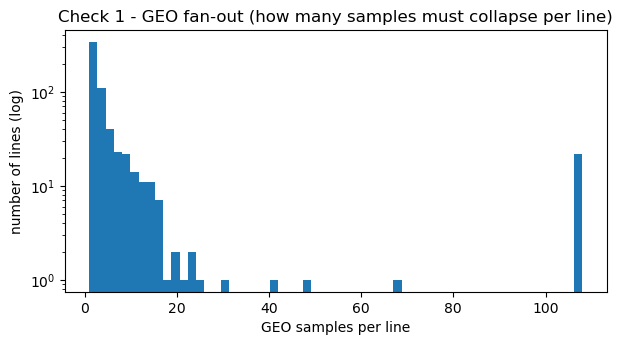

[fanout] depmap_expr 1,412 lines | max    2 / median 1 per line | 1.1% multi, 0.0% >=10, 0.0% >=50
[fanout] VERDICT: GEO median 2.0/line, max 108 - the tail, not the typical line, is the Q2 problem; DepMap fan-out is small (near-technical).

--- depmap_scale ---
[depmap-scale] common-gene set (from expr_long): mean 2.36, median 1.700, max 16.55, 19.1% zeros, skew 0.77
[depmap-scale] full matrix (53,961 ENSG cols): mean 1.09, median 0.014, max 16.67, 49.8% zeros, skew 2.02
[depmap-scale] VERDICT: DepMap is ~19% structural zeros on the set used for cross-source work - the appendix 'mean 3.40' was almost certainly computed on a denser/non-zero subset. Treat the zeros as real for Q1b.

--- hpa_cost ---
[hpa-cost] expr_long sources: {'geo': 93223284, 'depmap': 28408632} (HPA expected ABSENT)
[hpa-cost] expr_long covers 19,894 genes x 1,486 lines (the DepMap-GEO common set)
[hpa-cost] genes DepMap measured but expr_long drops (not on GEO): 34,067 - invisible to cross-source work, DepMap-only

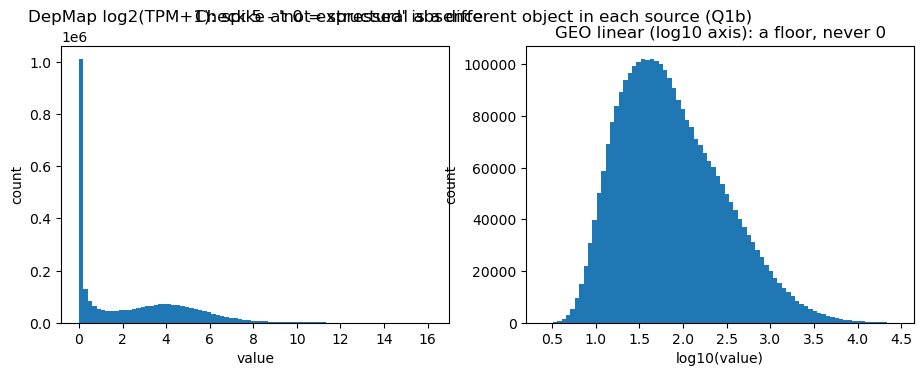

[absence] VERDICT: absence cannot be read off a shared continuous axis. Strongly points to a separate per-source detection layer (present / not-detected) for D2, rather than folding absence into one continuous value.

--- rank_agreement ---
[rank] lines measured by BOTH sources: 538
[rank] per_line: median Spearman 0.82 (IQR 0.81-0.83); 100% >=0.5, 99% >=0.7
[rank] per_gene: median Spearman 0.40 (IQR 0.14-0.57); 35% >=0.5, 12% >=0.7


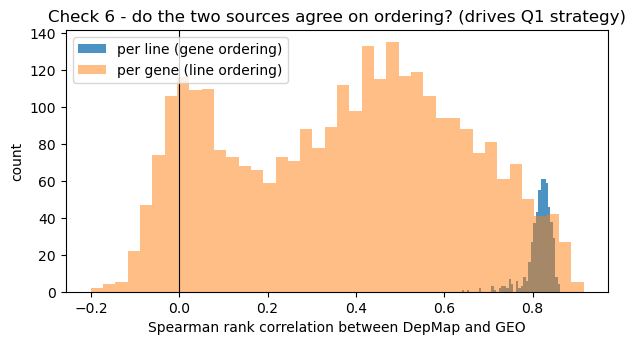

[rank] marker spotlight (line-ordering agreement per gene):
        VIM (mesenchymal)      n=538  Spearman=0.88
[rank] VERDICT: HIGH ordering agreement -> a rank/percentile or category representation reconciles the sources without a raw-scale merge. The 'keep separate + compare' / 'categorise' strategies are viable.

[run_all] wrote features/expr_diagnostics/expr_diagnostics_summary.json

READ THE RESULTS IN THIS ORDER:
  check 6 (rank agreement) first  -> decides which Q1 strategy is even needed
  check 5 (absence)               -> whether absence wants its own layer (D2)
  checks 1-4                      -> size the aggregation & scope the sources
Then read Q1/Q2 literature against these numbers, not in the abstract.


In [3]:
import importlib.util
import sys

module_path = "/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/src/scripts/03_expression_diagnostics.py"

spec = importlib.util.spec_from_file_location(
    "expression_diagnostics", module_path
)
diag = importlib.util.module_from_spec(spec)
sys.modules["expression_diagnostics"] = diag
spec.loader.exec_module(diag)

tables = {
    # "expr_long":   pd.read_parquet("path/to/expr_long.parquet"),
    "expr_long": expr_long,
    "depmap_expr": pd.read_parquet("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/harmonised_data/depmap_expr.parquet"),
    "geo_expr":    pd.read_parquet("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/harmonised_data/geo_expr.parquet"),
    "geo_info":    pd.read_parquet("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/harmonised_data/geo_info.parquet"),
    "hpa_rna":     pd.read_parquet("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/harmonised_data/hpa_rna.parquet"),
    "sample_info": pd.read_parquet("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/harmonised_data/sample_info.parquet"),
}
summary = diag.run_all(tables)   # skip any table you don't have; those checks self-skip

In [7]:
import pandas as pd, numpy as np

# fetch each frame whether it's a bare variable or only inside `tables`
hpa = globals().get('hpa_rna')
if hpa is None: hpa = tables.get('hpa_rna')
el = globals().get('expr_long')
if el is None: el = tables.get('expr_long')

# look at the RAW values and types, not astype(str) — the bug is hiding in the type/format
print("HPA model_id  :", hpa['model_id'].dropna().head(5).tolist())
print("HPA cell type :", type(hpa['model_id'].dropna().iloc[0]))
print("expr_long id  :", el['model_id'].dropna().head(5).tolist())
print("expr_long type:", type(el['model_id'].dropna().iloc[0]))

HPA model_id  : [array(['ach-001001'], dtype=object), array(['ach-000956'], dtype=object), array(['ach-000948'], dtype=object), array(['ach-000011'], dtype=object), array(['ach-000026'], dtype=object)]
HPA cell type : <class 'numpy.ndarray'>
expr_long id  : ['ach-001113', 'ach-001289', 'ach-001339', 'ach-001538', 'ach-000242']
expr_long type: <class 'str'>


In [9]:
def norm_ids(s):
    def to_list(v):
        if isinstance(v, np.ndarray): return v.tolist()
        if isinstance(v, (list, tuple, set)): return list(v)
        return [v]
    out = s.dropna().map(to_list).explode().dropna()
    return set(out.astype(str).str.strip().str.upper())

hpa_ids = norm_ids(hpa['model_id'])
el_ids  = norm_ids(el['model_id'])
print(f"HPA {len(hpa_ids)} | expr_long {len(el_ids)} | overlap {len(hpa_ids & el_ids)} "
      f"| HPA-only {len(hpa_ids - el_ids)}")
print("HPA examples      :", list(hpa_ids)[:5])
print("expr_long examples:", list(el_ids)[:5])

HPA 1127 | expr_long 1486 | overlap 1091 | HPA-only 36
HPA examples      : ['ACH-000914', 'ACH-000322', 'ACH-000283', 'ACH-000143', 'ACH-000849']
expr_long examples: ['ACH-000914', 'ACH-000322', 'ACH-000283', 'ACH-000511', 'ACH-000152']


 bin   n  med_spearman  med_info
   0 400      0.007041  0.069302
   1 400      0.116134  0.156650
   2 400      0.234698  0.173532
   3 399      0.362052  0.186782
   4 400      0.357962  0.200433
   5 400      0.438287  0.218329
   6 399      0.492004  0.240467
   7 400      0.547514  0.274809
   8 400      0.658772  0.335071
   9 400      0.769081  0.466797

High-variance decile median Spearman: 0.77  |  low-variance decile: 0.01


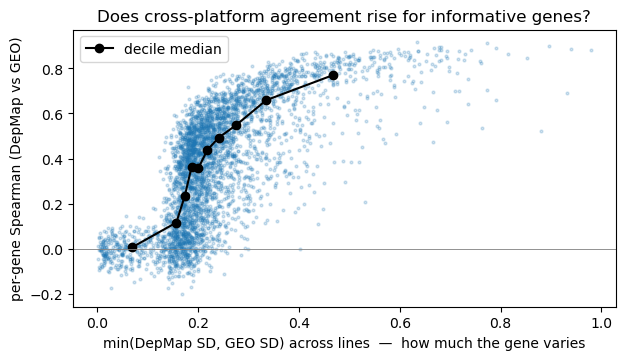

In [10]:
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt

el = globals().get('expr_long')
if el is None: el = tables['expr_long']
S_DM, S_GEO = 'depmap', 'geo'
mcol, gcol, vcol, scol = 'model_id', 'gene', 'value', 'source'

low = el[scol].astype(str).str.lower()
shared = set(el.loc[low==S_DM, mcol].astype(str)) & set(el.loc[low==S_GEO, mcol].astype(str))
gsample = set(random.Random(0).sample(list(el[gcol].astype(str).unique()),
                                      min(4000, el[gcol].nunique())))
sub = el[el[mcol].astype(str).isin(shared) & el[gcol].astype(str).isin(gsample)].copy()
sub['_s'] = sub[scol].astype(str).str.lower()
med = sub.groupby([mcol, gcol, '_s'])[vcol].median().reset_index()
wide = med.pivot_table(index=[mcol, gcol], columns='_s', values=vcol)

wdm  = wide[S_DM]
wgeo = np.log10(wide[S_GEO].clip(lower=1e-9))     # log GEO so its spread is comparable

def sp(a, b):
    m = a.notna() & b.notna()
    if m.sum() < 5: return np.nan
    ra, rb = a[m].rank(), b[m].rank()
    if ra.std(ddof=0)==0 or rb.std(ddof=0)==0: return np.nan
    return np.corrcoef(ra, rb)[0, 1]

rows = []
for g, idx in wide.groupby(level=1).groups.items():
    dm, ge = wdm.loc[idx], wgeo.loc[idx]; m = dm.notna() & ge.notna()
    if m.sum() < 20: continue           # need enough shared lines for a real per-gene corr
    rows.append({'gene': g, 'n': int(m.sum()), 'spearman': sp(dm, ge),
                 'dm_sd': float(dm[m].std()), 'geo_sd': float(ge[m].std())})
res = pd.DataFrame(rows).dropna(subset=['spearman'])
res['informative'] = res[['dm_sd','geo_sd']].min(axis=1)   # a gene must vary in BOTH sources
res['bin'] = pd.qcut(res['informative'], 10, labels=False, duplicates='drop')

by = res.groupby('bin').agg(n=('gene','size'), med_spearman=('spearman','median'),
                            med_info=('informative','median')).reset_index()
print(by.to_string(index=False))
print(f"\nHigh-variance decile median Spearman: {by.med_spearman.iloc[-1]:.2f}  |  "
      f"low-variance decile: {by.med_spearman.iloc[0]:.2f}")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(res['informative'], res['spearman'], s=4, alpha=0.2)
ax.plot(by['med_info'], by['med_spearman'], 'o-', color='k', label='decile median')
ax.axhline(0, color='grey', lw=0.6); ax.legend()
ax.set_xlabel('min(DepMap SD, GEO SD) across lines  —  how much the gene varies')
ax.set_ylabel('per-gene Spearman (DepMap vs GEO)')
ax.set_title('Does cross-platform agreement rise for informative genes?')
plt.show()

In [11]:
gcols = [c for c in geo_expr.columns if str(c).lower().startswith("ensg")]
idcol = "model_id"

print("geo_expr rows:", len(geo_expr))
print("rows with a model_id:", geo_expr[idcol].notna().sum())
# after the credit-both explode (what the melt actually consumes):
exploded = geo_expr.dropna(subset=[idcol]).explode(idcol)
print("rows after explode:", len(exploded))
print("expected geo_long rows:", len(exploded) * len(gcols))   # compare to 93.2M

# is there a duplicate-sample problem? check for a GSM/sample id column
print("columns:", [c for c in geo_expr.columns if not str(c).lower().startswith("ensg")])
# if a GSM column exists:
for c in geo_expr.columns:
    if "gsm" in str(c).lower() or "accession" in str(c).lower() or "sample" in str(c).lower():
        print(f"duplicate {c}:", geo_expr[c].duplicated().sum())

geo_expr rows: 3267
rows with a model_id: 2416
rows after explode: 4686
expected geo_long rows: 93317004
columns: ['sample', 'model_id']
duplicate sample: 0


DepMap: model_id + 53961 ENSG cols | HPA cols -> model_id gene ntpm
shared lines 1042 | DepMap∩HPA genes 19896 | sampled 4000


/var/folders/w4/fbz2zhr165g6wr5k09mtgl9r0000gn/T/ipykernel_7686/3137559737.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_line = m.groupby('_mid').apply(lambda g: sp(g['dm'], g['hpa'])).dropna()



per-line Spearman: median 0.96 (IQR 0.95-0.96); 100% >=0.7
 bin   n  med_spearman  med_info
   0 399      0.386042  0.034128
   1 398      0.661081  0.119096
   2 399      0.755657  0.156033
   3 398      0.790639  0.177082
   4 399      0.804733  0.197529
   5 398      0.837294  0.225071
   6 398      0.862137  0.270244
   7 399      0.902601  0.341145
   8 398      0.930145  0.428078
   9 399      0.959115  0.599642
high-variance decile 0.96 | low-variance decile 0.39


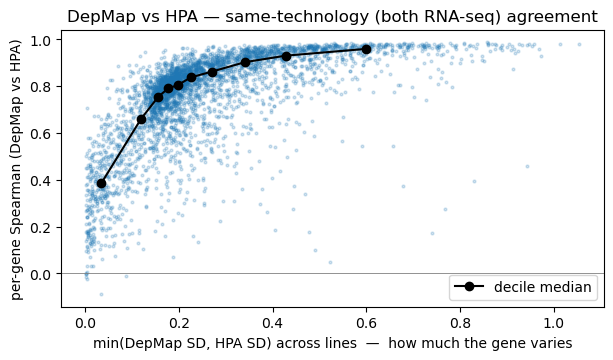

In [12]:
import numpy as np, pandas as pd, random
import matplotlib.pyplot as plt

de = globals().get('depmap_expr');  de = tables['depmap_expr'] if de is None else de
hp = globals().get('hpa_rna');      hp = tables['hpa_rna']     if hp is None else hp

def unwrap(v):                         # 1-element-array / list cells -> scalar
    if isinstance(v, np.ndarray): return v[0] if v.size else np.nan
    if isinstance(v, (list, tuple)): return v[0] if len(v) else np.nan
    return v
def norm_gene(g): return str(g).strip().lower().split('.')[0]
def sp(a, b):
    m = a.notna() & b.notna()
    if m.sum() < 5: return np.nan
    ra, rb = a[m].rank(), b[m].rank()
    if ra.std(ddof=0) == 0 or rb.std(ddof=0) == 0: return np.nan
    return np.corrcoef(ra, rb)[0, 1]

# --- resolve columns (prints what it picked so you can confirm) ---
dm_id = 'model_id'
dm_gene_cols = [c for c in de.columns if str(c).lower().startswith('ensg')]
hpc = {c.lower(): c for c in hp.columns}
hp_id  = hpc.get('model_id')
hp_gene = next((hpc[k] for k in ('gene','ensembl','ensembl_id','gene_id','ensg') if k in hpc), None)
hp_val  = next((hpc[k] for k in ('ntpm','ptpm','tpm','value') if k in hpc), None)
print("DepMap: model_id +", len(dm_gene_cols), "ENSG cols | HPA cols ->", hp_id, hp_gene, hp_val)
assert hp_id and hp_gene and hp_val, "resolve HPA columns manually if this fails"

# --- normalise ids/genes on both sides (HPA nTPM = its cross-sample-normalised value) ---
dm_norm_id = de[dm_id].map(unwrap).astype(str).str.strip().str.upper()
hp2 = pd.DataFrame({'_mid': hp[hp_id].map(unwrap).astype(str).str.strip().str.upper(),
                    '_gene': hp[hp_gene].map(unwrap).map(norm_gene),
                    '_val': pd.to_numeric(hp[hp_val], errors='coerce')}).dropna(subset=['_val'])

shared = set(dm_norm_id) & set(hp2['_mid'])
shared_genes = {norm_gene(c) for c in dm_gene_cols} & set(hp2['_gene'].unique())
gsample = set(random.Random(0).sample(sorted(shared_genes), min(4000, len(shared_genes))))
print(f"shared lines {len(shared)} | DepMap∩HPA genes {len(shared_genes)} | sampled {len(gsample)}")

# --- DepMap: melt sampled shared genes, median-collapse profiles (usually 1/line) ---
gene_to_col = {norm_gene(c): c for c in dm_gene_cols if norm_gene(c) in gsample}
de2 = de.copy(); de2['_mid'] = dm_norm_id; de2 = de2[de2['_mid'].isin(shared)]
dm_long = de2.melt(id_vars=['_mid'], value_vars=list(gene_to_col.values()),
                   var_name='_col', value_name='dm')
dm_long['_gene'] = dm_long['_col'].map(norm_gene)
dm_med = dm_long.groupby(['_mid','_gene'])['dm'].median().reset_index()

# --- HPA: already one value per (line,gene); collapse defensively ---
hp_sub = hp2[hp2['_mid'].isin(shared) & hp2['_gene'].isin(gsample)]
hp_med = hp_sub.groupby(['_mid','_gene'])['_val'].median().reset_index().rename(columns={'_val':'hpa'})

m = dm_med.merge(hp_med, on=['_mid','_gene'], how='inner')
m['hpa_log'] = np.log10(m['hpa'].clip(lower=0) + 1)     # log HPA so its SD is comparable to DepMap-log

# --- per-line ordering agreement (rank-invariant, so raw hpa is fine) ---
per_line = m.groupby('_mid').apply(lambda g: sp(g['dm'], g['hpa'])).dropna()
print(f"\nper-line Spearman: median {per_line.median():.2f} "
      f"(IQR {per_line.quantile(.25):.2f}-{per_line.quantile(.75):.2f}); "
      f"{(per_line>=0.7).mean()*100:.0f}% >=0.7")

# --- per-gene, variance-stratified (same lens as the GEO check) ---
rows = []
for gene, g in m.groupby('_gene'):
    if len(g) < 20: continue
    rows.append({'gene':gene,'n':len(g),'spearman':sp(g['dm'],g['hpa']),
                 'dm_sd':g['dm'].std(),'hpa_sd':g['hpa_log'].std()})
res = pd.DataFrame(rows).dropna(subset=['spearman'])
res['informative'] = res[['dm_sd','hpa_sd']].min(axis=1)
res['bin'] = pd.qcut(res['informative'], 10, labels=False, duplicates='drop')
by = res.groupby('bin').agg(n=('gene','size'), med_spearman=('spearman','median'),
                            med_info=('informative','median')).reset_index()
print(by.to_string(index=False))
print(f"high-variance decile {by.med_spearman.iloc[-1]:.2f} | low-variance decile {by.med_spearman.iloc[0]:.2f}")

fig, ax = plt.subplots(figsize=(7,3.6))
ax.scatter(res['informative'], res['spearman'], s=4, alpha=0.2)
ax.plot(by['med_info'], by['med_spearman'], 'o-', color='k', label='decile median')
ax.axhline(0, color='grey', lw=0.6); ax.legend()
ax.set_xlabel('min(DepMap SD, HPA SD) across lines  —  how much the gene varies')
ax.set_ylabel('per-gene Spearman (DepMap vs HPA)')
ax.set_title('DepMap vs HPA — same-technology (both RNA-seq) agreement')
plt.show()

In [13]:
de = globals().get('depmap_expr');  de = tables['depmap_expr'] if de is None else de
ge = globals().get('geo_expr');     ge = tables['geo_expr']    if ge is None else ge

def explode_vals(s):
    def tl(v):
        if isinstance(v, np.ndarray): return v.tolist()
        if isinstance(v, (list,tuple,set)): return list(v)
        try:
            if pd.isna(v): return []
        except (TypeError, ValueError): return []
        return [v]
    return s.map(tl).explode().dropna()

geo_ensg = [c for c in ge.columns if str(c).lower().startswith('ensg')]
dm_ensg  = [c for c in de.columns if str(c).lower().startswith('ensg')]
common   = sorted(set(map(str.lower, map(str, geo_ensg))) & set(map(str.lower, map(str, dm_ensg))))
print(f"common genes: {len(common):,}   (expect 19,894)")

# --- GEO sample bookkeeping: where do the rows come from? ---
n_raw          = len(ge)
n_with_id      = ge['model_id'].notna().sum()
n_after_explode = len(explode_vals(ge['model_id']))
print(f"\nGEO rows raw:            {n_raw:,}")
print(f"GEO rows with model_id: {n_with_id:,}   (drop {n_raw - n_with_id:,} unmatched)")
print(f"GEO rows after explode: {n_after_explode:,}   (credit-both adds {n_after_explode - n_with_id:,})")
print(f"=> predicted geo_long rows: {n_after_explode * len(common):,}   (rebuild had 93,223,284)")

# --- duplicate-sample test: the prime suspect for a ~2x blow-up ---
non_ensg = [c for c in ge.columns if not str(c).lower().startswith('ensg')]
print("\nnon-ENSG columns:", non_ensg)
for c in ge.columns:
    lc = str(c).lower()
    if any(k in lc for k in ('gsm','accession','sample','cel_file','title')):
        dups = ge[c].astype(str).duplicated().sum()
        print(f"  duplicated in '{c}': {dups:,} of {len(ge):,}")

# --- is the whole row duplicated (same sample melted twice)? ---
dup_full = ge.duplicated(subset=[c for c in non_ensg if ge[c].map(lambda v: not isinstance(v,(list,np.ndarray))).all()]).sum()
print(f"\nfully-duplicated metadata rows: {dup_full:,}")

# --- if expr_long is still in memory, get its real per-source split for comparison ---
el = globals().get('expr_long')
if el is not None:
    print("\ncurrent expr_long source split:", el['source'].astype(str).str.lower().value_counts().to_dict())

common genes: 19,894   (expect 19,894)

GEO rows raw:            3,267
GEO rows with model_id: 2,416   (drop 851 unmatched)
GEO rows after explode: 4,686   (credit-both adds 2,270)
=> predicted geo_long rows: 93,223,284   (rebuild had 93,223,284)

non-ENSG columns: ['sample', 'model_id']
  duplicated in 'sample': 0 of 3,267

fully-duplicated metadata rows: 0

current expr_long source split: {'geo': 93223284, 'depmap': 28408632}


In [15]:
import importlib.util

script_path = "/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/src/scripts/04_biotype_annotation.py"

spec = importlib.util.spec_from_file_location("biotype_annotation", script_path)
bt = importlib.util.module_from_spec(spec)
spec.loader.exec_module(bt)

ensg_ids = [c for c in depmap_expr.columns if str(c).lower().startswith("ensg")]
ann = bt.build_biotype_annotation(ensg_ids, gtf_path="Homo_sapiens.GRCh38.111.gtf.gz")
# -> features/gene_biotype.parquet, one row per gene:
#    gene, gene_biotype, biotype_coarse, gene_name, is_protein_coding, in_default_universe

[biotype] source: Homo_sapiens.GRCh38.111.gtf.gz
[biotype] genes: 53,961 | matched 53,801 (99.7%) | unmatched 160
[biotype] PROTEIN-CODING (default universe): 19,903 (36.9%)
[biotype] coarse biotype distribution:
           protein_coding    19,903 ( 36.9%)
           lncRNA            16,623 ( 30.8%)
           pseudogene        13,983 ( 25.9%)
           small_ncRNA        1,968 (  3.6%)
           other              1,050 (  1.9%)
           IG_TR_gene           274 (  0.5%)
           unmatched            160 (  0.3%)
[biotype] wrote features/gene_biotype.parquet
